Encoding Demonstration
Original data: [1, 0, 1, 1, 0, 0, 1, 0, 1]
NRZ-L signal:  [1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0, 1.0]
NRZ-I signal:  [1.0, 1.0, -1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1.0]
Decoded NRZ-L: [1, 0, 1, 1, 0, 0, 1, 0, 1]
Decoded NRZ-I: [0, 1, 1, 0, 0, 1, 0, 1]
NRZ-L errors:  0
NRZ-I errors:  0

NRZ Encoding Characteristics Analysis
NRZ-L (Non-Return-to-Zero Level):
  • 1 bit → +V, 0 bit → -V
  • Simple implementation
  • DC component varies with data
  • Susceptible to polarity inversion
  • Clock recovery challenging with long runs

NRZ-I (Non-Return-to-Zero Inverted):
  • 1 bit → transition, 0 bit → no transition
  • Differential encoding
  • Better DC balance on average
  • Immune to polarity inversion
  • Still challenging for clock recovery
  • Loses one bit during decoding process

Running comprehensive error rate test...
Testing NRZ-L vs NRZ-I Error Rates
Noise σ=0.00: NRZ-L=0.0000, NRZ-I=0.0000
Noise σ=0.11: NRZ-L=0.0000, NRZ-I=0.0000
Noise σ=0.21: NRZ-L=0.0000

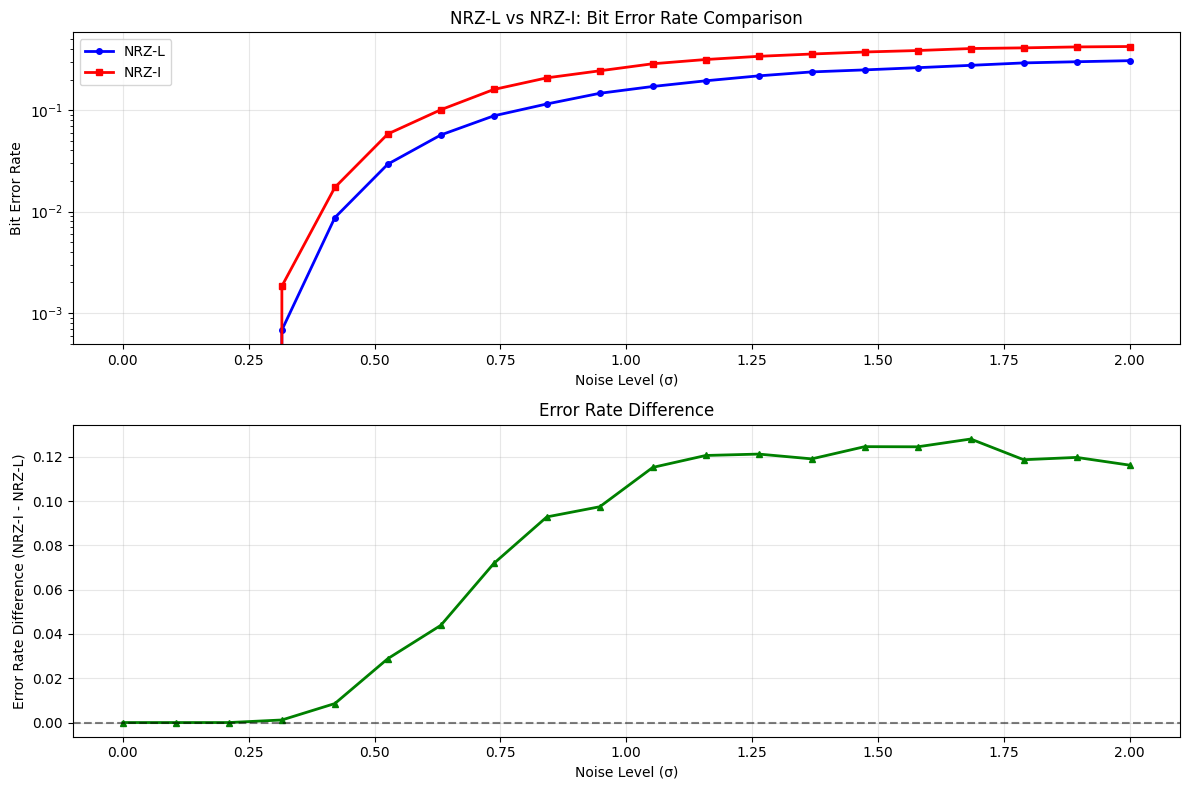


Summary Analysis:
Conditions where NRZ-L performs better: 17/20
Conditions where NRZ-I performs better: 0/20

Low noise (σ=0.53):
  NRZ-L: 0.029340
  NRZ-I: 0.058198

High noise (σ=1.58):
  NRZ-L: 0.261620
  NRZ-I: 0.386126


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import List, Tuple
# Updating the new libraries soon like surprize and all...

class NRZEncoder:
    """Implementation of NRZ-L and NRZ-I encoding schemes"""
    
    def __init__(self):
        self.nrz_i_state = 0  # Initial state for NRZ-I (0 = low, 1 = high)
    
    def nrz_l_encode(self, data: List[int]) -> List[float]:
        """
        NRZ-L encoding: 1 -> +1V, 0 -> -1V
        """
        return [1.0 if bit else -1.0 for bit in data]


        // adding
    
    def nrz_i_encode(self, data: List[int]) -> List[float]:
        """
        NRZ-I encoding: 1 -> transition, 0 -> no transition
        """
        encoded = []
        current_state = self.nrz_i_state
        
        for bit in data:
            if bit == 1:  # Transition on '1'
                current_state = 1 - current_state
            # No transition on '0'
            encoded.append(1.0 if current_state else -1.0)
        
        return encoded
    
    def nrz_l_decode(self, signal: List[float]) -> List[int]:
        """
        NRZ-L decoding: +V -> 1, -V -> 0
        """
        return [1 if sample > 0 else 0 for sample in signal]
    
    def nrz_i_decode(self, signal: List[float]) -> List[int]:
        """
        NRZ-I decoding: transition -> 1, no transition -> 0
        """
        if not signal:
            return []
        
        decoded = []
        prev_state = 1 if signal[0] > 0 else 0
        
        for i in range(1, len(signal)):
            current_state = 1 if signal[i] > 0 else 0
            if current_state != prev_state:
                decoded.append(1)  # Transition detected
            else:
                decoded.append(0)  # No transition
            prev_state = current_state
        
        return decoded

def add_noise(signal: List[float], noise_level: float) -> List[float]:
    """Add Gaussian noise to the signal"""
    return [sample + np.random.normal(0, noise_level) for sample in signal]

def generate_random_data(length: int) -> List[int]:
    """Generate random binary data"""
    return [random.randint(0, 1) for _ in range(length)]

def calculate_error_rate(original: List[int], decoded: List[int]) -> float:
    """Calculate bit error rate"""
    if len(original) != len(decoded):
        # Handle length mismatch (NRZ-I loses first bit in decoding)
        min_len = min(len(original), len(decoded))
        original = original[:min_len]
        decoded = decoded[:min_len]
    
    errors = sum(1 for o, d in zip(original, decoded) if o != d)
    return errors / len(original) if original else 0

def run_error_rate_test(data_length: int = 1000, num_trials: int = 100):
    """Run error rate comparison test"""
    encoder = NRZEncoder()
    noise_levels = np.linspace(0, 2, 20)  # Noise standard deviation from 0 to 2
    
    nrz_l_errors = []
    nrz_i_errors = []
    
    print("Testing NRZ-L vs NRZ-I Error Rates")
    print("=" * 40)
    
    for noise_level in noise_levels:
        l_total_errors = 0
        i_total_errors = 0
        
        for trial in range(num_trials):
            # Generate random data
            data = generate_random_data(data_length)
            
            # Reset NRZ-I state for each trial
            encoder.nrz_i_state = 0
            
            # Encode with both schemes
            nrz_l_signal = encoder.nrz_l_encode(data)
            nrz_i_signal = encoder.nrz_i_encode(data)
            
            # Add noise
            noisy_l_signal = add_noise(nrz_l_signal, noise_level)
            noisy_i_signal = add_noise(nrz_i_signal, noise_level)
            
            # Decode
            decoded_l = encoder.nrz_l_decode(noisy_l_signal)
            decoded_i = encoder.nrz_i_decode(noisy_i_signal)
            
            # Calculate error rates
            l_error_rate = calculate_error_rate(data, decoded_l)
            i_error_rate = calculate_error_rate(data[1:], decoded_i)  # Skip first bit for NRZ-I
            
            l_total_errors += l_error_rate
            i_total_errors += i_error_rate
        
        # Average error rates across trials
        avg_l_error = l_total_errors / num_trials
        avg_i_error = i_total_errors / num_trials
        
        nrz_l_errors.append(avg_l_error)
        nrz_i_errors.append(avg_i_error)
        
        print(f"Noise σ={noise_level:.2f}: NRZ-L={avg_l_error:.4f}, NRZ-I={avg_i_error:.4f}")
    
    return noise_levels, nrz_l_errors, nrz_i_errors

def plot_results(noise_levels, nrz_l_errors, nrz_i_errors):
    """Plot error rate comparison"""
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(noise_levels, nrz_l_errors, 'b-o', label='NRZ-L', linewidth=2, markersize=4)
    plt.plot(noise_levels, nrz_i_errors, 'r-s', label='NRZ-I', linewidth=2, markersize=4)
    plt.xlabel('Noise Level (σ)')
    plt.ylabel('Bit Error Rate')
    plt.title('NRZ-L vs NRZ-I: Bit Error Rate Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Show difference
    plt.subplot(2, 1, 2)
    difference = np.array(nrz_i_errors) - np.array(nrz_l_errors)
    plt.plot(noise_levels, difference, 'g-^', linewidth=2, markersize=4)
    plt.xlabel('Noise Level (σ)')
    plt.ylabel('Error Rate Difference (NRZ-I - NRZ-L)')
    plt.title('Error Rate Difference')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def demonstrate_encoding():
    """Demonstrate encoding with example data"""
    encoder = NRZEncoder()
    
    # Example data
    data = [1, 0, 1, 1, 0, 0, 1, 0, 1]
    print("Encoding Demonstration")
    print("=" * 25)
    print(f"Original data: {data}")
    
    # NRZ-L encoding
    nrz_l_signal = encoder.nrz_l_encode(data)
    print(f"NRZ-L signal:  {nrz_l_signal}")
    
    # NRZ-I encoding
    encoder.nrz_i_state = 0  # Reset state
    nrz_i_signal = encoder.nrz_i_encode(data)
    print(f"NRZ-I signal:  {nrz_i_signal}")
    
    # Test decoding (without noise)
    decoded_l = encoder.nrz_l_decode(nrz_l_signal)
    decoded_i = encoder.nrz_i_decode(nrz_i_signal)
    
    print(f"Decoded NRZ-L: {decoded_l}")
    print(f"Decoded NRZ-I: {decoded_i}")
    print(f"NRZ-L errors:  {sum(1 for o, d in zip(data, decoded_l) if o != d)}")
    print(f"NRZ-I errors:  {sum(1 for o, d in zip(data[1:], decoded_i) if o != d)}")
    print()

def analyze_characteristics():
    """Analyze key characteristics of both encoding schemes"""
    print("NRZ Encoding Characteristics Analysis")
    print("=" * 40)
    print("NRZ-L (Non-Return-to-Zero Level):")
    print("  • 1 bit → +V, 0 bit → -V")
    print("  • Simple implementation")
    print("  • DC component varies with data")
    print("  • Susceptible to polarity inversion")
    print("  • Clock recovery challenging with long runs")
    print()
    print("NRZ-I (Non-Return-to-Zero Inverted):")
    print("  • 1 bit → transition, 0 bit → no transition")
    print("  • Differential encoding")
    print("  • Better DC balance on average")
    print("  • Immune to polarity inversion")
    print("  • Still challenging for clock recovery")
    print("  • Loses one bit during decoding process")
    print()

if __name__ == "__main__":
    # Set random seed for reproducible results
    np.random.seed(42)
    random.seed(42)
    
    # Demonstrate basic encoding
    demonstrate_encoding()
    
    # Analyze characteristics
    analyze_characteristics()
    
    # Run comprehensive error rate test
    print("Running comprehensive error rate test...")
    noise_levels, nrz_l_errors, nrz_i_errors = run_error_rate_test(
        data_length=1000, 
        num_trials=50
    )
    
    # Plot results
    plot_results(noise_levels, nrz_l_errors, nrz_i_errors)
    
    # Summary analysis
    print("\nSummary Analysis:")
    print("=" * 20)
    
    # Find crossover point
    difference = np.array(nrz_i_errors) - np.array(nrz_l_errors)
    better_nrz_l = np.sum(difference > 0)
    better_nrz_i = np.sum(difference < 0)
    
    print(f"Conditions where NRZ-L performs better: {better_nrz_l}/{len(noise_levels)}")
    print(f"Conditions where NRZ-I performs better: {better_nrz_i}/{len(noise_levels)}")
    
    # Average error rates at different noise levels
    low_noise_idx = len(noise_levels) // 4
    high_noise_idx = 3 * len(noise_levels) // 4
    
    print(f"\nLow noise (σ={noise_levels[low_noise_idx]:.2f}):")
    print(f"  NRZ-L: {nrz_l_errors[low_noise_idx]:.6f}")
    print(f"  NRZ-I: {nrz_i_errors[low_noise_idx]:.6f}")
    
    print(f"\nHigh noise (σ={noise_levels[high_noise_idx]:.2f}):")
    print(f"  NRZ-L: {nrz_l_errors[high_noise_idx]:.6f}")
    print(f"  NRZ-I: {nrz_i_errors[high_noise_idx]:.6f}")

In [ ]:
df_1 = _dntk.execute_sql(
  '',
  'SQL_DEEPNOTE_DATAFRAME_SQL',
  audit_sql_comment='',
  sql_cache_mode='cache_disabled',
  return_variable_type='dataframe'
)
df_1